Convection Variance 
=====
***

A one-dimensional stochastic model for the convective power in the core. The buoyancy source is generated by a series of impulsive (delta function) events. The timing of each event obeys a Poisson process and the amplitude $a$ is assumed to be a constant. A timescale $\tau_p$ defines the decay of buoyancy through turbulent entrainment.

In [3]:
using Plots
using Distributions
using StatsBase
using DelimitedFiles

Draw event times from an exponential distribution

In [5]:
myr = 1.0e6;
kyr = 1.0e3;
sectoyear = 365.25 * 24 * 3600;

recurrence = 0.35/kyr;      # average recurrence time (in kyr)
λ = 1 / recurrence;         # average recurrence rate (in kyr^-1)

nevents = 660000;
tevent = rand(Exponential(recurrence),nevents);  # Poisson event times

# plot distribution of event times
println("mean recurrence time = ",mean(tevent)," kyr")
#histogram(tevent,label="event times",xlabel="event time (Myr)",ylabel="Number")

mean recurrence time = 0.0003506427240027568 kyr


Set convective amplitude and entrainment time

In [7]:
a = 23.8e9 
τp = 46.4/kyr;

Integrate equations for the variable power p(t). 

In [9]:
P = zeros(nevents);
t = zeros(nevents);

# decay rate for convective power (gamma_p = 1/tau_p)
γp = 1/τp;    

# initial condition
t[1] = 0.0;
P[1] = λ * a * τp;     # use time average as IC

# integrate of number of events
for i = 2 : nevents
    
    # integrate over time step dt
    dt = tevent[i];
    t[i] = t[i-1] + dt;
    P[i] = P[i-1] * exp(-γp * dt) + a;
    
end

t[end] = t[end-1]
P[end] = P[end-1]

println("mean P = ",mean(P)," std P = ",std(P))

mean P = 3.1732478002093477e12 std P = 1.9366244228205646e11


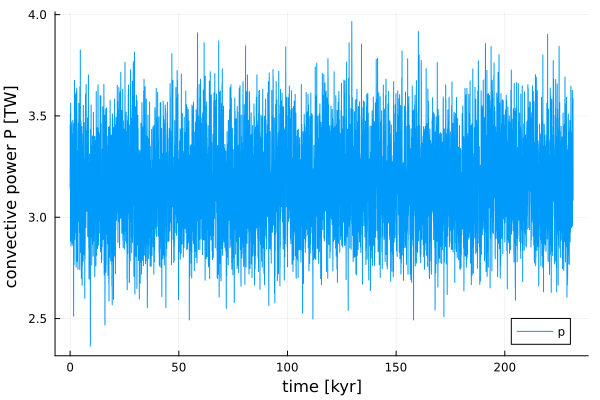

In [10]:
idecimate = 20;
plot(t[1:idecimate:end],(P[1:idecimate:end]/1.0e12),
    label="p",xlabel="time [kyr]",
    ylabel="convective power P [TW] ")


In [11]:
# save to file ?
save_file = false
      
if save_file
    open("power_data.txt","w")  do io
        writedlm(io,[t p])
    end
end

Evaluate mean and variance from theory

In [13]:
pmean = λ * a * τp
pvariance = 0.5 * λ * a^2 * τp
pstd = sqrt(pvariance)
println(pmean,"  ",pstd)

3.1552e12  1.937701731433401e11


Integrate for magnetic energy

In [15]:
τm_avg = 33.6/kyr
m = zeros(nevents);

# constants
ρ = 1.1e4;
b = 3.48e6;
c = 1.22e6;
V = 4 * pi * (b^3 - c^3) / 3.0;
pd = P / (ρ * V)

m[1] = mean(pd) * τm_avg * kyr * sectoyear

for i = 1 : nevents-1

    # time step
    dt = (t[i+1] - t[i])*kyr*sectoyear;
    τm = τm_avg * (0.75 * m[i]/m[1] + 0.25);
    m[i+1] = m[i] + 2 * pd[i] * dt - 2 * m[i]/(τm*kyr*sectoyear) * dt;
end

println("mean ",mean(m),'\n',
    "std ",std(m),'\n',
    "ratio ",std(m)/mean(m))

mean 0.001844135992044908
std 0.0002895293500469254
ratio 0.15699999961818153


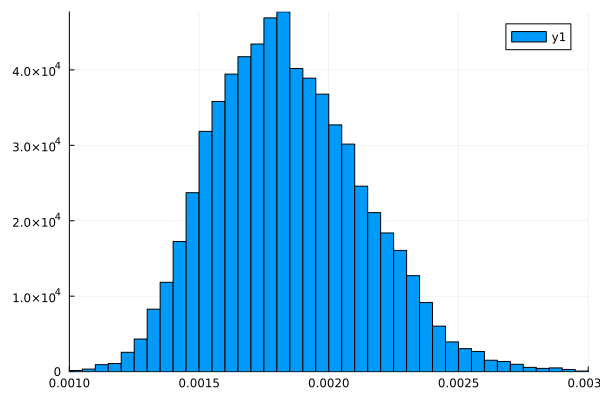

In [16]:
h = fit(Histogram,m,nbins=100)
plot(h,xlim=(0.001,0.003))

In [17]:
# save to file ?
save_file = false
      
if save_file
    open("m_data.txt","w")  do io
        writedlm(io,[t m])
    end
end

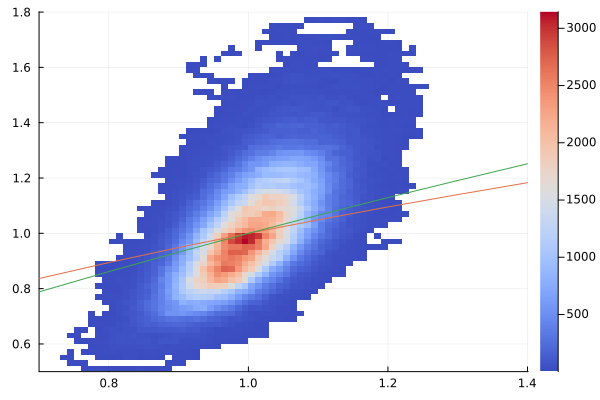

In [18]:
pplot= (0 : 0.1 : 1.4)
histogram2d(P/mean(P),m/mean(m),color=:coolwarm,xlim=(0.7,1.401),ylim=(0.5,1.801))
plot!(pplot,pplot.^(.5),legend=nothing)
plot!(pplot,pplot.^(2/3),legend=nothing)